# ⚙️ Word2Vec (Skip-gram) 밑바닥부터 구현하기

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 시드 고정
torch.manual_seed(42)

## 1. 장난감 데이터셋 및 전처리
단순한 코퍼스를 만들고, 단어-인덱스 매핑 사전을 생성합니다.

In [2]:
corpus = [
    "i like deep learning",
    "i like natural language processing",
    "deep learning is fun",
    "natural language processing is cool"
]

# 단어 사전 구축
words = list(set(" ".join(corpus).split()))
word2idx = {w: i for i, w in enumerate(words)}
idx2word = {i: w for i, w in enumerate(words)}
vocab_size = len(words)

print(f"단어 사전 크기: {vocab_size}")
print(f"단어 사전: {word2idx}")

단어 사전 크기: 10
단어 사전: {'processing': 0, 'natural': 1, 'fun': 2, 'cool': 3, 'like': 4, 'deep': 5, 'language': 6, 'is': 7, 'i': 8, 'learning': 9}


## 2. Skip-gram 쌍 생성
중심 단어(Target)를 보고 주변 단어(Context)를 예측하기 위한 훈련 쌍을 만듭니다. (Window size = 1)

In [3]:
skip_grams = []
window_size = 1

for sentence in corpus:
    tokens = sentence.split()
    for i, target in enumerate(tokens):
        target_idx = word2idx[target]
        
        # 좌우 윈도우 내의 주변 단어들
        contexts = []
        if i - window_size >= 0:
            contexts.append(tokens[i - window_size])
        if i + window_size < len(tokens):
            contexts.append(tokens[i + window_size])
            
        for context in contexts:
            skip_grams.append((target_idx, word2idx[context]))

print(f"생성된 훈련 데이터 쌍 개수: {len(skip_grams)}")
print(f"예시: {[ (idx2word[t], idx2word[c]) for t, c in skip_grams[:5] ]}")

생성된 훈련 데이터 쌍 개수: 28
예시: [('i', 'like'), ('like', 'i'), ('like', 'deep'), ('deep', 'like'), ('deep', 'learning')]


## 3. PyTorch nn.Embedding 신경망 훈련
두 개의 임베딩 행렬(중심 단어용, 주변 단어용)을 만들어 내적을 통해 확률을 높이도록 학습시킵니다.

In [4]:
embedding_dim = 2 # 시각화를 위해 2차원으로 극단적 압축

class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        # 1. 중심 단어 임베딩 행렬
        self.u_embeddings = nn.Embedding(vocab_size, emb_dim)
        # 2. 주변 단어 임베딩 행렬 (분류용 가중치 역할)
        self.v_embeddings = nn.Embedding(vocab_size, emb_dim)
        
    def forward(self, target_idx, context_idx):
        # (batch, emb_dim)
        u = self.u_embeddings(target_idx)
        v = self.v_embeddings(context_idx)
        # 내적 (Dot Product)
        score = torch.sum(u * v, dim=1)
        return score

model = SkipGramModel(vocab_size, embedding_dim)
criterion = nn.BCEWithLogitsLoss() # 이진 교차 엔트로피 (내적값이 커지도록)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 데이터 텐서 변환
targets = torch.tensor([pair[0] for pair in skip_grams])
contexts = torch.tensor([pair[1] for pair in skip_grams])
labels = torch.ones(len(skip_grams)) # 실제 존재하는 쌍이므로 정답은 1

# 훈련 루프
epochs = 500
for epoch in range(epochs):
    optimizer.zero_grad()
    scores = model(targets, contexts)
    loss = criterion(scores, labels)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1:03d} | Loss: {loss.item():.4f}")

print("✅ 학습 완료!")

Epoch 100 | Loss: 0.3022
Epoch 200 | Loss: 0.1195


Epoch 300 | Loss: 0.0466
Epoch 400 | Loss: 0.0099


Epoch 500 | Loss: 0.0044
✅ 학습 완료!


## 4. 단어 공간 2D 시각화 (PCA 역할)
학습된 임베딩 벡터를 2차원 산점도로 그려서 단어들이 어떻게 뭉쳐있는지 확인합니다.

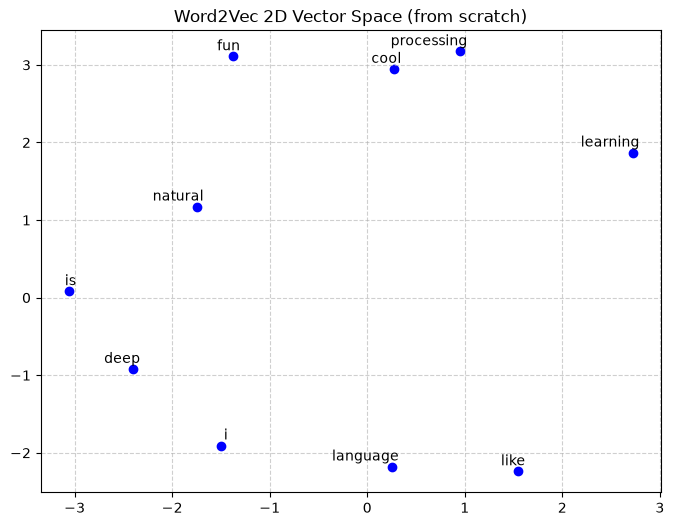

💡 같이 등장하는 단어들(예: deep-learning, natural-language)이 기하학적으로 가까워지는 경향을 보입니다!


In [5]:
# 중심 단어 임베딩 행렬 가중치 추출
word_vectors = model.u_embeddings.weight.data.numpy()

plt.figure(figsize=(8, 6))
for i, word in idx2word.items():
    x, y = word_vectors[i]
    plt.scatter(x, y, color='blue')
    plt.annotate(word, (x, y), xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')

plt.title("Word2Vec 2D Vector Space (from scratch)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("💡 같이 등장하는 단어들(예: deep-learning, natural-language)이 기하학적으로 가까워지는 경향을 보입니다!")